# Momentum Backtest

Run the reusable momentum backtest from `src.backtest` and evaluate results with `src.metrics`.

In [1]:
import os
import sys
from collections import Counter
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

sys.path.append(os.path.abspath(".."))

from src.backtest import momentum_score, run_factor_backtest
from src.metrics import (
    calculate_drawdown,
    calculate_growth,
    calculate_performance_metrics,
)
from src.data_loader import load_prices


In [2]:
prices = load_prices()

prices.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267067,136.742584,59.450500,88.292412,282.886444,131.293930,102.634384,30.269533,88.640511,106.224533,...,78.699913,56.421844,4.922530,72.280701,127.825684,110.094940,191.993927,107.888268,33.712959,28.800236
2018-01-03,40.260056,139.322922,60.209999,88.836761,283.801239,131.494583,103.499405,30.511000,89.286644,106.680588,...,79.066154,56.412956,5.246499,72.193016,128.338608,110.445290,194.007950,108.962341,33.020180,29.051460
2018-01-04,40.447071,138.735779,60.479500,90.314377,282.724426,133.300430,104.865768,30.597324,89.008743,106.633102,...,79.762062,56.377396,5.274155,72.703300,127.640305,110.445290,194.850067,109.367455,33.127235,29.077755
2018-01-05,40.907574,139.562393,61.457001,90.520378,294.322296,135.407272,106.261612,31.021099,88.862823,106.053513,...,80.750977,56.857292,5.318851,72.751152,130.285141,110.245102,198.565598,111.986679,33.051666,29.250099
2018-01-08,40.755630,139.523743,62.343498,89.687538,295.570740,138.810013,107.008705,31.342840,89.300529,104.533279,...,80.833359,57.363834,5.481824,73.133881,131.008148,109.652817,195.119110,112.438934,32.994987,29.682446


In [3]:
portfolio, holdings_history = run_factor_backtest(
    prices,
    score_function=partial(momentum_score, lookback=252),
    top_n=5,
    strategy_name="Momentum Strategy",
)

portfolio.head()


2019-02-28    0.062411
2019-03-31    0.015893
2019-04-30    0.035743
2019-05-31   -0.039095
2019-06-30    0.064664
Name: Momentum Strategy, dtype: float64

In [4]:
portfolio.describe()

count    71.000000
mean      0.018782
std       0.057274
min      -0.109865
25%      -0.013450
50%       0.015893
75%       0.053095
max       0.172792
Name: Momentum Strategy, dtype: float64

<Axes: title={'center': 'Momentum Strategy Returns'}>

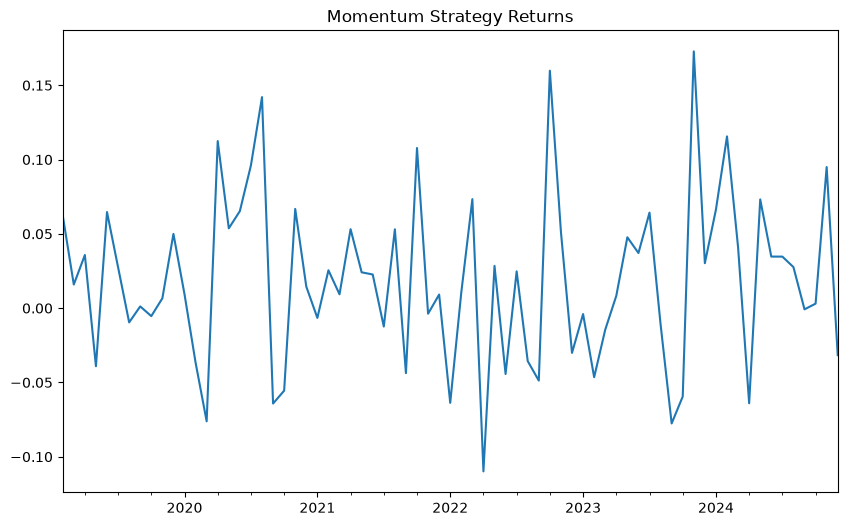

In [5]:
portfolio.plot(
    title="Momentum Strategy Returns",
    figsize=(10, 6),
)

<Axes: title={'center': 'Momentum Strategy Growth of $1'}, ylabel='Portfolio Value'>

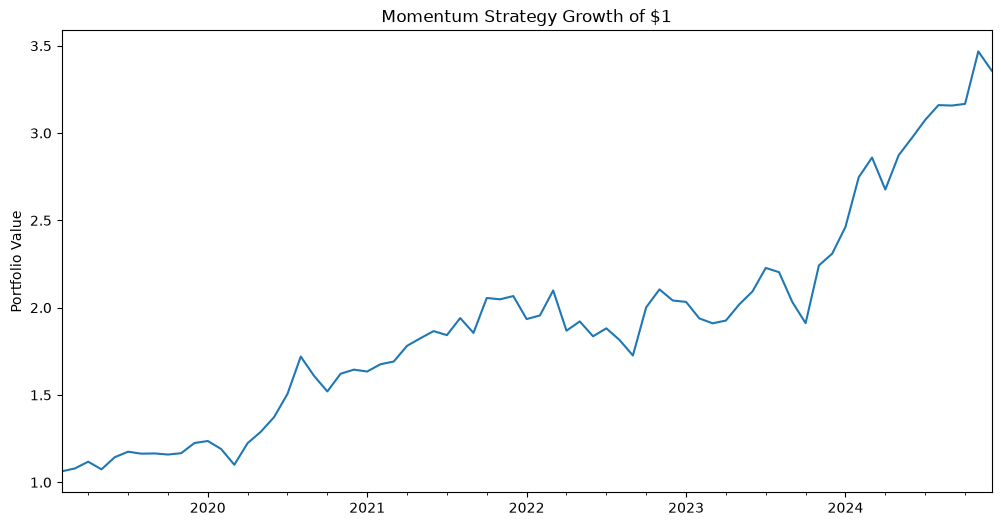

In [6]:
portfolio_growth = calculate_growth(portfolio)

portfolio_growth.plot(
    figsize=(12, 6),
    title="Momentum Strategy Growth of $1",
    ylabel="Portfolio Value",
)

Text(0, 0.5, 'Drawdown')

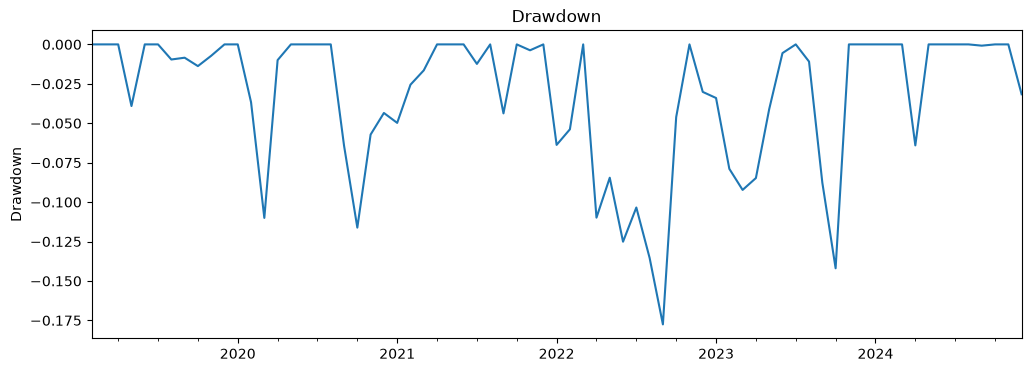

In [7]:
drawdown = calculate_drawdown(portfolio_growth)

ax = drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
)
ax.set_ylabel("Drawdown")

In [8]:
momentum_metrics = calculate_performance_metrics(portfolio)

momentum_metrics

CAGR                 0.230520
Annual Return        0.225387
Annual Volatility    0.198403
Sharpe Ratio         1.136003
Max Drawdown        -0.177543
dtype: float64

In [9]:
spy = yf.download(
    "SPY",
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
)

spy_close = spy["Close"]["SPY"] if isinstance(spy["Close"], pd.DataFrame) else spy["Close"]
spy_returns = spy_close.resample("ME").last().pct_change().loc[portfolio.index]
spy_growth = calculate_growth(spy_returns)

spy_returns.head()

[*********************100%***********************]  1 of 1 completed


2019-02-28    0.032416
2019-03-31    0.018101
2019-04-30    0.040852
2019-05-31   -0.063771
2019-06-30    0.069586
Name: SPY, dtype: float64

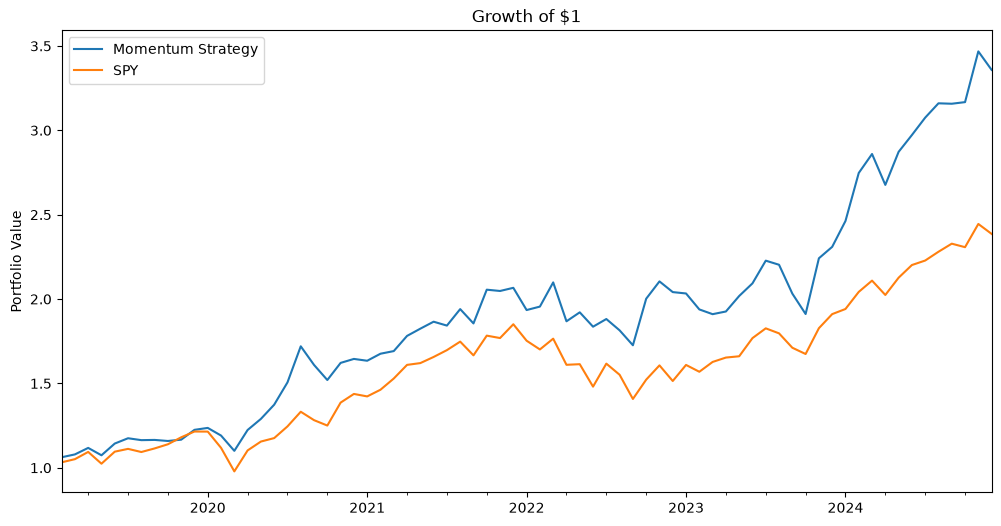

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

portfolio_growth.plot(ax=ax, label="Momentum Strategy")
spy_growth.plot(ax=ax, label="SPY")

ax.set_title("Growth of $1")
ax.set_ylabel("Portfolio Value")
ax.legend()

plt.show()

In [11]:
spy_metrics = calculate_performance_metrics(spy_returns)

comparison = pd.DataFrame({
    "Momentum Strategy": momentum_metrics,
    "SPY": spy_metrics,
})

comparison_formatted = comparison.copy()
percent_rows = [
    "CAGR",
    "Annual Return",
    "Annual Volatility",
    "Max Drawdown",
]

comparison_formatted.loc[percent_rows] = (
    comparison_formatted.loc[percent_rows] * 100
).round(2)
comparison_formatted.loc["Sharpe Ratio"] = comparison_formatted.loc[
    "Sharpe Ratio"
].round(2)

comparison_formatted

,Momentum Strategy,SPY
CAGR,23.05,16.06
Annual Return,22.54,16.27
Annual Volatility,19.84,17.30
Sharpe Ratio,1.14,0.94
Max Drawdown,-17.75,-23.93


The momentum strategy outperformed SPY over the backtest period, achieving a higher CAGR and Sharpe ratio while also experiencing a slightly smaller maximum drawdown. Although the strategy had higher annual volatility, its superior risk-adjusted return suggests that the momentum factor added value relative to the benchmark.

In [12]:
all_holdings = [
    stock
    for holdings in holdings_history["holdings"]
    for stock in holdings
]

holding_counts = (
    pd.Series(Counter(all_holdings))
    .sort_values(ascending=False)
)

holding_counts

NVDA    50
MSFT    30
AAPL    27
MRK     23
AMZN    20
CAT     19
CVX     17
CRM     16
AXP     16
GS      16
JPM     16
AMGN    12
PG      11
UNH     10
BA       9
KO       8
SHW      7
MCD      7
DIS      6
NKE      6
IBM      6
TRV      5
MMM      5
HD       4
V        4
WMT      3
CSCO     1
VZ       1
dtype: int64

NVDA appears frequently in the holdings history, indicating that the strategy is heavily exposed to NVDA. Another run of the same strategy will be done, excluding NVDA.

In [13]:
prices_no_nvda = prices.drop(columns=["NVDA"])

portfolio_no_nvda, holdings_history_no_nvda = run_factor_backtest(
    prices_no_nvda,
    score_function=partial(momentum_score, lookback=252),
    top_n=5,
    strategy_name="Momentum Strategy",
)

portfolio_no_nvda.head()


2019-02-28    0.062411
2019-03-31    0.015893
2019-04-30    0.035743
2019-05-31   -0.039095
2019-06-30    0.064664
Name: Momentum Strategy, dtype: float64

In [14]:
portfolio_growth_no_nvda = calculate_growth(portfolio_no_nvda)

portfolio_growth_no_nvda.tail()

2024-08-31    1.930941
2024-09-30    1.938406
2024-10-31    1.913629
2024-11-30    2.125682
2024-12-31    2.052342
Name: Momentum Strategy, dtype: float64

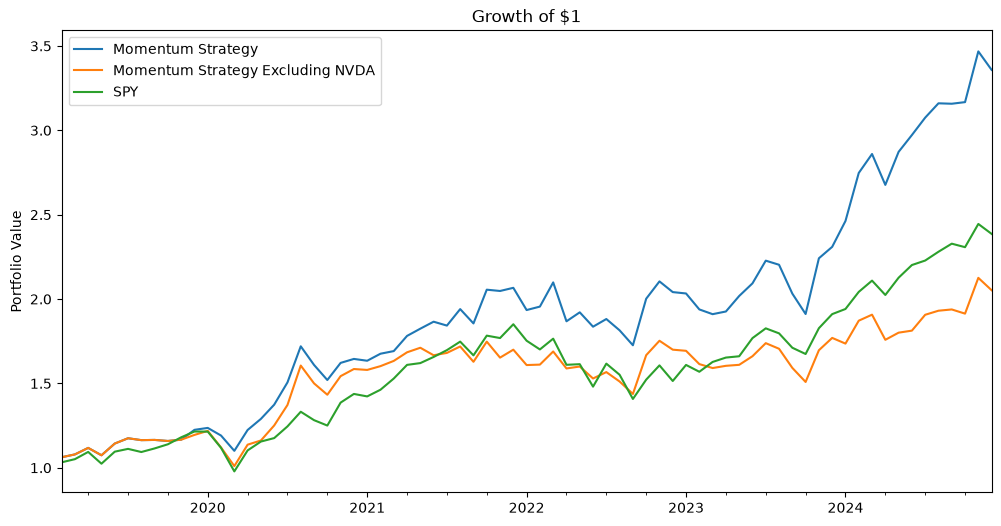

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

portfolio_growth.plot(ax=ax, label="Momentum Strategy")
portfolio_growth_no_nvda.plot(ax=ax, label="Momentum Strategy Excluding NVDA")
spy_growth.plot(ax=ax, label="SPY")

ax.set_title("Growth of $1")
ax.set_ylabel("Portfolio Value")
ax.legend()

plt.show()

In [16]:
no_nvda_metrics = calculate_performance_metrics(portfolio_no_nvda)

comparison_3 = pd.DataFrame({
    "Momentum Strategy": momentum_metrics,
    "Momentum Ex-NVDA": no_nvda_metrics,
    "SPY": spy_metrics,
})

comparison_3

,Momentum Strategy,Momentum Ex-NVDA,SPY
CAGR,0.230520,0.131016,0.160590
Annual Return,0.225387,0.139623,0.162722
Annual Volatility,0.198403,0.191080,0.173038
Sharpe Ratio,1.136003,0.730701,0.940384
Max Drawdown,-0.177543,-0.177414,-0.239272


In [17]:
comparison.to_csv("../data/performance_comparison.csv")
holdings_history.to_csv("../data/holdings_history.csv", index=False)